# Binary Group Composition on $C_n$

**Group:** Cyclic group $C_n$ of order $p$ (i.e., modular addition mod $p$).  
**Task:** Given encodings of two group elements $a, b \in C_p$, predict the encoding of their product $a + b \pmod{p}$.  
**Sequence length:** $k = 2$ (binary composition).  
**Architecture:** `TwoLayerMLP` with square nonlinearity.  
**Key result:** The network learns one Fourier mode at a time, producing a staircase in the training loss.

## Imports

In [1]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import src.dataset as dataset
import src.model as model
import src.optimizer as optimizer
import src.power as power
import src.template as template
import src.train as train_mod
import src.viz as viz

## Configuration

In [2]:
TEST_MODE = os.environ.get("NOTEBOOK_TEST_MODE", "0") == "1"

seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

p = 11
hidden_dim = 20 if TEST_MODE else 200
epochs = 2 if TEST_MODE else 5000
lr = 0.01
init_scale = 1e-5

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

## Template and Dataset

In [ ]:
# Build a fixed Cn template with known Fourier structure
tpl = template.fixed_cn(
    group_size=p,
    powers=[0.0, 200.0, 100.0, 50.0, 20.0, 5.0],
)


# Build exhaustive dataset: all group_size^2 pairs
pair_ds = dataset.GroupCompositionDataset("cn", group_size=p, template=tpl, k=2, mode="exhaustive")

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N = len(pair_ds)
X_tensor = pair_ds.X.to(device)
Y_tensor = pair_ds.Y.to(device)

ds = TensorDataset(X_tensor, Y_tensor)
dataloader = DataLoader(ds, batch_size=len(ds), shuffle=False)

print(f"Group: C_{p}, order {p}")
print(f"Dataset: {len(ds)} samples (all {p}x{p} pairs)")
print(f"X shape: {X_tensor.shape}, Y shape: {Y_tensor.shape}")

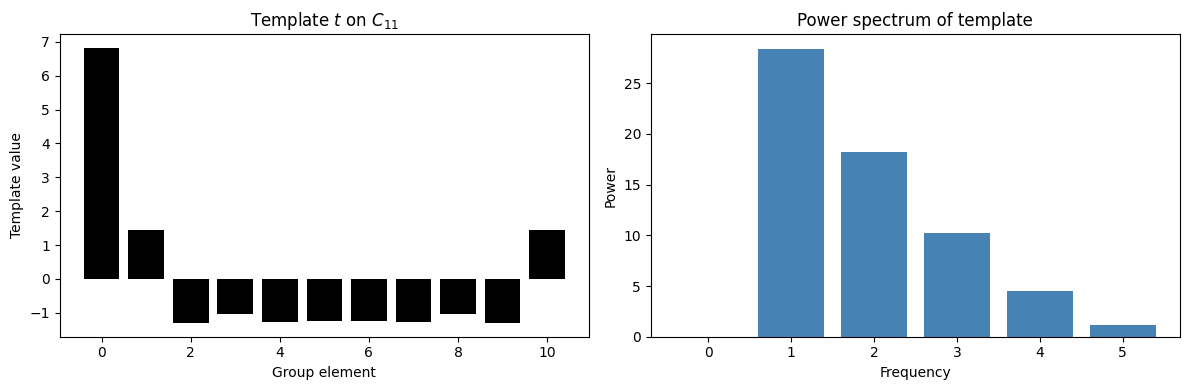

In [4]:
# Visualize template and its power spectrum
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(range(p), tpl, color="black")
ax1.set_xlabel("Group element")
ax1.set_ylabel("Template value")
ax1.set_title(f"Template $t$ on $C_{{{p}}}$")

pwr, freqs = power.get_power_1d(tpl)
ax2.bar(freqs, pwr, color="steelblue")
ax2.set_xlabel("Frequency")
ax2.set_ylabel("Power")
ax2.set_title("Power spectrum of template")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/cn_template.pdf", bbox_inches="tight")
plt.show()

## Model and Optimizer

In [5]:
net = model.TwoLayerMLP(
    group_size=p,
    hidden_dim=hidden_dim,
    k=2,
    nonlinearity="square",
    init_scale=init_scale,
)
net = net.to(device)

criterion = nn.MSELoss()
opt = optimizer.PerNeuronScaledSGD(net, lr=lr, degree=2)

print(f"Model: TwoLayerMLP(group_size={p}, hidden_dim={hidden_dim}, init_scale={init_scale})")
print(f"Optimizer: PerNeuronScaledSGD(lr={lr}, degree=2)")
print(f"Training for {epochs} epochs")

Model: TwoLayerNet(p=11, hidden=200, init_scale=1e-05)
Optimizer: PerNeuronScaledSGD(lr=0.01, degree=3)
Training for 5000 epochs


## Training

In [6]:
loss_history, val_loss_history, param_history, param_save_epochs, final_epoch = train_mod.train(
    net,
    dataloader,
    criterion,
    opt,
    epochs=epochs,
    verbose_interval=max(1, epochs // 10),
    save_param_interval=1,
)

[Epoch   500/5000] loss: 0.141917 | reduction:   97.5%
[Epoch  1000/5000] loss: 0.103960 | reduction:   98.2%
[Epoch  1500/5000] loss: 0.103631 | reduction:   98.2%
[Epoch  2000/5000] loss: 0.103321 | reduction:   98.2%
[Epoch  2500/5000] loss: 0.103311 | reduction:   98.2%
[Epoch  3000/5000] loss: 0.103157 | reduction:   98.2%
[Epoch  3500/5000] loss: 0.101198 | reduction:   98.2%
[Epoch  4000/5000] loss: 0.095021 | reduction:   98.3%
[Epoch  4500/5000] loss: 0.083760 | reduction:   98.5%
[Epoch  5000/5000] loss: 0.069925 | reduction:   98.8%


## Training Loss

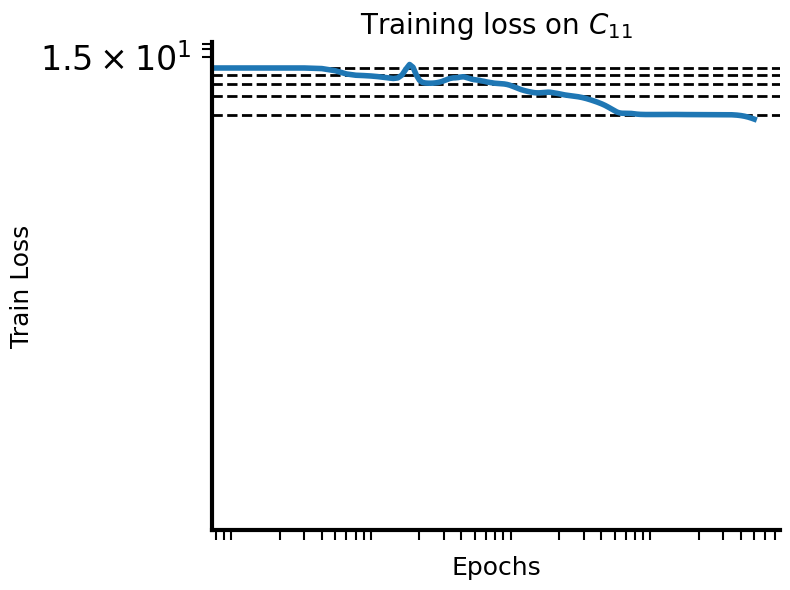

In [7]:
# Compute theoretical loss plateau levels
theory = power.theoretical_loss_levels_1d(tpl)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(loss_history, lw=4)

for level in theory["levels"]:
    ax.axhline(y=level, color="black", linestyle="--", linewidth=2, zorder=-2)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Epochs", fontsize=18)
ax.set_ylabel("Train Loss", fontsize=18)
ax.set_title(f"Training loss on $C_{{{p}}}$", fontsize=20)
viz.style_axes(ax)
ax.grid(False)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/cn_loss.pdf", bbox_inches="tight")
plt.show()

## Power Spectrum Over Training

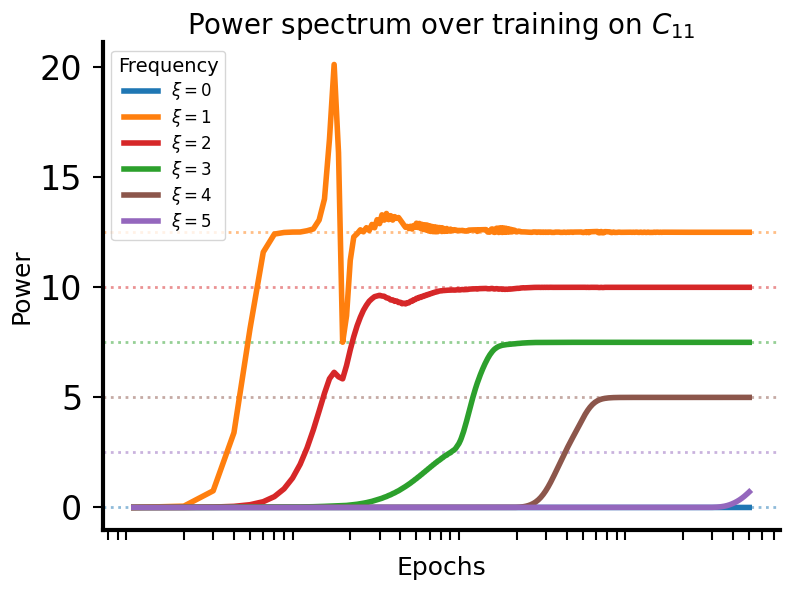

In [8]:
# Compute template power for reference lines
num_freqs = p // 2 + 1
template_ft = np.fft.rfft(tpl)
template_power = np.abs(template_ft)[:num_freqs]

# Compute output power over time
num_points = min(500, len(param_history))
steps = np.unique(np.logspace(0, np.log10(max(1, len(param_history) - 1)), num_points, dtype=int))
powers_over_time = []

for step in steps:
    net.load_state_dict(param_history[step])
    net.eval()
    with torch.no_grad():
        outputs = net(X_tensor)
        ft = np.fft.rfft(outputs.detach().cpu().numpy(), axis=1)
        avg_power = np.mean(np.abs(ft), axis=0)
        powers_over_time.append(avg_power)

powers_over_time = np.array(powers_over_time)

# Plot
colors = ["tab:blue", "tab:orange", "tab:red", "tab:green", "tab:brown", "tab:purple"]
fig, ax = plt.subplots(figsize=(8, 6))

for k in range(num_freqs):
    color = colors[k] if k < len(colors) else f"C{k}"
    ax.plot(steps, powers_over_time[:, k], color=color, lw=4, label=rf"$\xi = {k}$")
    ax.axhline(template_power[k], color=color, linestyle="dotted", linewidth=2, alpha=0.5, zorder=-10)

ax.set_xscale("log")
ax.set_ylabel("Power", fontsize=18)
ax.set_xlabel("Epochs", fontsize=18)
ax.set_title(f"Power spectrum over training on $C_{{{p}}}$", fontsize=20)
ax.legend(fontsize=12, title="Frequency", title_fontsize=14, loc="upper left", labelspacing=0.25)
viz.style_axes(ax)
ax.grid(False)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/cn_power_spectrum.pdf", bbox_inches="tight")
plt.show()